In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset + the frozen train/test split (src/split.py). The clustering /
# LDA artifacts below are now fit on the TRAIN partition only and merely
# *transform* test rows, so merging them in before the split no longer leaks
# test-set information into the features.
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

df = load_rtr_with_split()
_n_rows = len(df)

# Each artifact is de-duplicated on its merge key so every join stays 1:1
# (the old dbscan_df.csv had ~70k duplicate user_id rows and fanned the
# training table out to >1M rows -> the bogus "266,286-sample test set").

# GMM clusters
gmm = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")
    [["user_id", "item_id", "body_cluster", "cluster_confidence"]]
    .drop_duplicates(subset=["user_id", "item_id"])
)

# DBSCAN clusters (one row per user_id)
dbscan = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")
    [["user_id", "dbscan_cluster"]]
    .drop_duplicates(subset=["user_id"])
)

# K-Means clusters
kmeans = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv")
    .rename(columns={"cluster": "kmeans_cluster"})
    .drop_duplicates(subset=["user_id", "item_id"])
)

# LDA topic features
lda = (
    pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
    .drop_duplicates(subset=["user_id", "item_id", "fit", "fit_label"])
)

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
assert len(df) == _n_rows, f"merge fan-out: {len(df)} rows != {_n_rows}"
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
# Use the frozen split carried on df["split"] instead of a fresh
# train_test_split — this is the same partition the clustering / LDA models
# were fit on, so no test row influenced any feature.
_train_mask = (df["split"].to_numpy() == "train")

X_train_full, X_test = X[_train_mask], X[~_train_mask]
y_train_full, y_test = y[_train_mask], y[~_train_mask]

print(f"train rows: {len(X_train_full):,}    test rows: {len(X_test):,}")

train rows: 154,035    test rows: 38,509


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # --- Body measurements: PCA removed ---
        (
            "num",                             
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
                # ← PCA line deleted
            ]),
            NUMERIC_FEATURES
        ),

        # --- Topic distributions: unchanged ---
        (
            "topics",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            TOPIC_FEATURES
        ),

        # --- Cluster features (categorical): unchanged ---
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # --- Binary features: unchanged ---
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [13]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = CalibratedClassifierCV(
    LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=2000
    )
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", svm)
])

In [15]:
param_grid = {
    "model__estimator__C": [0.1, 1, 10]
}

In [16]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

N_SVM = 30_000

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=N_SVM,
    random_state=42
)

for idx, _ in sss.split(X_train_full, y_train_full):
    X_train_svm = X_train_full.iloc[idx]
    y_train_svm = y_train_full.iloc[idx]

In [18]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_svm, y_train_svm)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(sparse_threshold=0.0,
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['height_inches',
                                                                          'weight_lbs',
                                                                          'bmi',
                                                                          'age',
                                                                          'bust_band',
                                                                          'cup_size_num']),
                                                                        ('topics',
                                                                         Pipeline(st...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['dbscan_cluster',
                                                                          'body_cluster',
                                                                          'kmeans_cluster']),
                                                                        ('bin',
                                                                         SimpleImputer(fill_value=0,
                                                                                       strategy='constant'),
                                                                         ['is_outlier'])])),
                                       ('model',
                                        CalibratedClassifierCV(estimator=LinearSVC(class_weight='balanced',
                                                                                   max_iter=2000,
                                                                                   random_state=42)))]),
             n_jobs=-1, param_grid={'model__estimator__C': [0.1, 1, 10]},
             scoring='f1_macro', verbose=2)

In [19]:
best_svm = grid.best_estimator_

y_test_pred = best_svm.predict(X_test)

print("Best Linear SVM parameters:")
print(grid.best_params_)

print("\nLinear SVM — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Linear SVM parameters:
{'model__estimator__C': 0.1}

Linear SVM — Test Set Performance
              precision    recall  f1-score   support

       Small       0.24      0.00      0.01      5156
         Fit       0.74      1.00      0.85     28412
       Large       0.33      0.01      0.01      4941

    accuracy                           0.74     38509
   macro avg       0.44      0.34      0.29     38509
weighted avg       0.62      0.74      0.63     38509



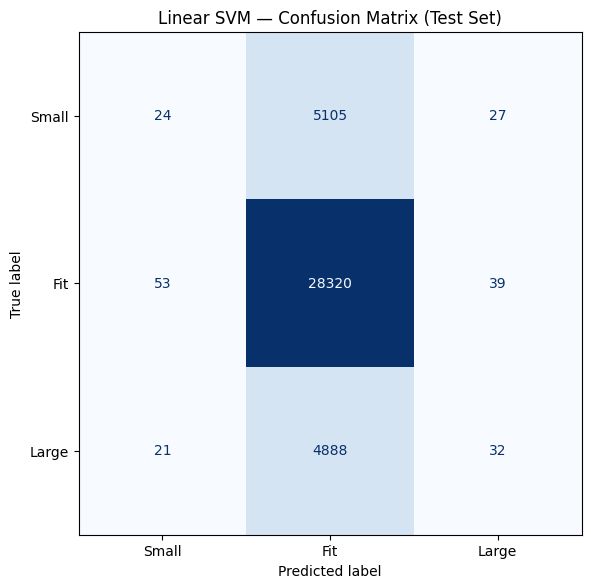

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Linear SVM — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/Linear_svm_confusion_matrix.png", dpi=300)
plt.show()

In [21]:
svm_proba = best_svm.predict_proba(X_test)

svm_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": svm_proba[:, 0],
    "prob_fit": svm_proba[:, 1],
    "prob_large": svm_proba[:, 2]
})

svm_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/linear_svm_fit_probabilities.csv",
    index=False
)

In [22]:
prep = best_svm.named_steps["prep"]

feature_names = []
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
feature_names.extend(
    cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
)

feature_names.extend(BINARY_FEATURES)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/linear_svm_feature_names.csv",
    index=False
)

In [23]:
import joblib

joblib.dump(
    best_svm,
    "../../Models/linear_svm_fit_classifier.joblib"
)

['../../Models/linear_svm_fit_classifier.joblib']

> **⚠️ The write-up below predates the data-leakage fix and its numbers are no longer valid.**
>
> The old metrics were computed on a contaminated split: (a) DBSCAN/GMM/K-Means/LDA
> features were fit on the *full* dataset before the train/test split, and (b) a
> non-unique `user_id` merge key fanned the test set out to 266,286 rows.
>
> After the fix (clustering/LDA fit on the training partition only; test set =
> **38,509 rows**), this model's grid search selected `C=0.1` and scored:
>
> | | Accuracy | Macro-F1 | F1 Small | F1 Fit | F1 Large |
> |---|---|---|---|---|---|
> | **leaky (old)** | ~0.68 | ~0.39 | — | — | — |
> | **fixed (new)** | **0.74** | **0.29** | 0.01 | 0.85 | 0.01 |
>
> The narrative, tables, and cross-model claims below need rewriting against the
> fixed numbers. Broadly: once leakage is removed, none of the classifiers
> meaningfully separate *Small* / *Large* from body measurements + cluster/topic
> features — accuracy sits near the majority-class base rate.

---

Overall Verdict: The model is heavily biased toward "Fit"
The best C=0.1 (very low regularization strength) suggests the model prefers a wide-margin, simple boundary — which in this case means it's taking the easy route of predicting "Fit" for almost everything.

Class-by-Class Breakdown

"Fit" (174k samples — the majority class)

Recall of 0.95 means it catches nearly all true Fit cases
But this is easy — it's just predicting Fit most of the time
The model is essentially over-relying on this class

"Large" (57k samples)

Precision 0.53, recall 0.26 — it misses ~74% of actual Large cases
Moderate when it does predict Large, but rarely bothers to

"Small" (34k samples — minority class)

Recall of 0.01 — essentially never predicts Small
This class is being almost completely ignored
F1 of 0.01 is nearly useless